In [1]:
import scipy
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import h5py

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.multiclass import OneVsOneClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report

from scipy import stats

from spike_generator import generate_spikes

In [2]:
# load data
mat_lambda = scipy.io.loadmat(Path('data') / 'lambda_slow-gain.mat')
rate = mat_lambda['lambda']
mat_tuning = scipy.io.loadmat(Path('data') / 'tuning_slow-gain.mat')
tuning_curves = mat_tuning['tuning_curves']
mat_gain = scipy.io.loadmat(Path('data') / 'gain_slow-gain.mat')
gain = mat_gain['gain']

mat2 = scipy.io.loadmat(Path('data') / 'bin_sizes_all.mat')
bin_sizes_all = mat2['bin_sizes_all'][0]
# ibin = 11
ibin = -3

n_neurons = rate.shape[0]
n_trials = rate.shape[2]

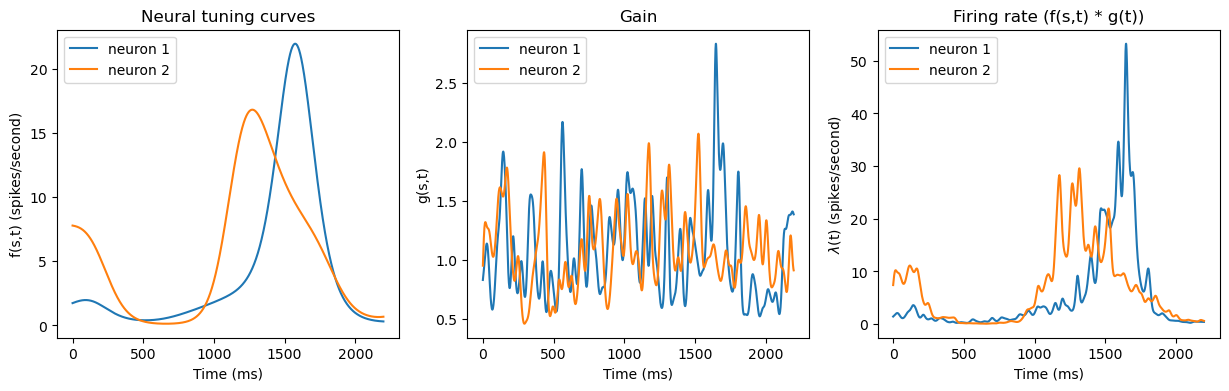

In [3]:
# pick two neurons only
neuron_idx = [12, 14]
# neuron_idx = [14]

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(tuning_curves[neuron_idx, :, 0].T)
axs[0].set_xlabel('Time (ms)')
axs[0].set_ylabel('f(s,t) (spikes/second)')
axs[0].set_title('Neural tuning curves')
axs[0].legend(('neuron 1','neuron 2'))

axs[1].plot(gain[neuron_idx, :, 0].T)
axs[1].set_xlabel('Time (ms)')
axs[1].set_ylabel('g(s,t)')
axs[1].set_title('Gain')
axs[1].legend(('neuron 1','neuron 2'))

axs[2].plot(rate[neuron_idx, :, 0].T)
axs[2].set_xlabel('Time (ms)')
axs[2].set_ylabel(r'$\lambda$(t) (spikes/second)')
axs[2].set_title('Firing rate (f(s,t) * g(t))')
axs[2].legend(('neuron 1','neuron 2'))

plt.show()

In [4]:
# simulate spikes
dt = 1e-3
spike_train = generate_spikes(rate[neuron_idx], dt) # create population response vectors

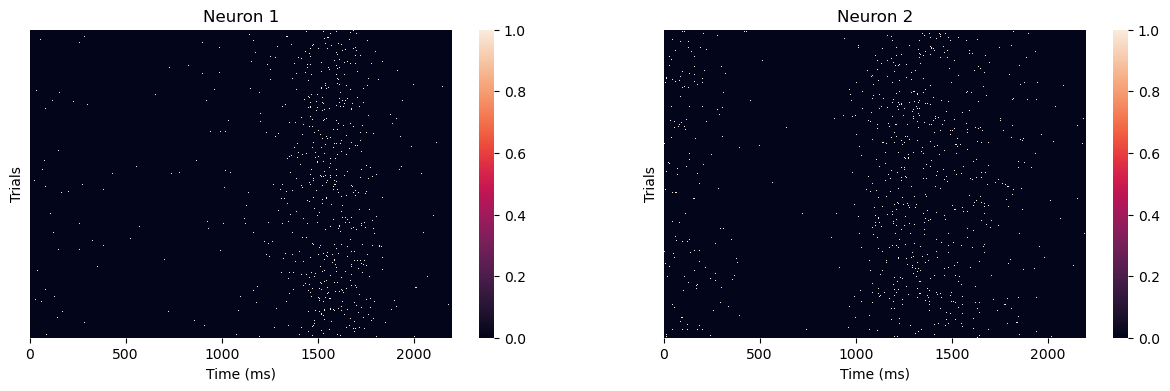

In [5]:
# plot spike trains
ticks = np.arange(0, spike_train.shape[1], 500)

fig, axs = plt.subplots(1, 2, figsize=(15, 4))

sns.heatmap(spike_train[0].T, ax=axs[0], yticklabels=False)
axs[0].set_title('Neuron 1')

sns.heatmap(spike_train[1].T, ax=axs[1], yticklabels=False)
axs[1].set_title('Neuron 2')

for i in range(2):
    axs[i].set_xlabel('Time (ms)')
    axs[i].set_ylabel('Trials')
    axs[i].set_xticks(ticks)
    axs[i].set_xticklabels(ticks)
    axs[i].tick_params(axis='x', labelrotation=0)

plt.show()

In [6]:
# create population response vectors; the number of bins determine the number of representational locations
bin_length = int(bin_sizes_all[ibin] / dt)
n_bins = int(spike_train.shape[1] // bin_length)
spike_train_reshaped = np.reshape(spike_train, (len(neuron_idx), n_bins, bin_length, n_trials)) # n_neurons x n_bins x bin_length x n_trials
mean_spike_train = np.sum(spike_train_reshaped, axis=2) # n_neurons x n_bins x n_trials

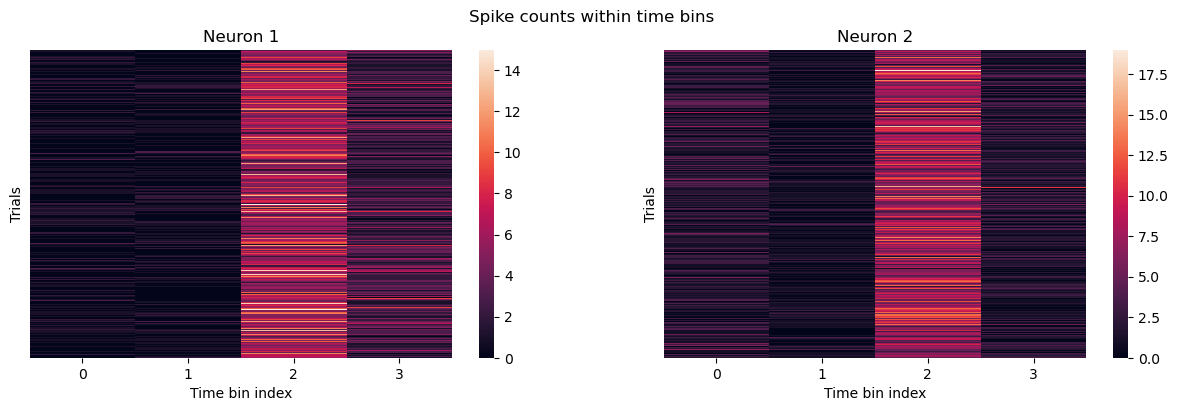

In [7]:
# plot binned spike counts
ticks = np.arange(0, spike_train.shape[1], 500)

fig, axs = plt.subplots(1, 2, figsize=(15, 4))

sns.heatmap(mean_spike_train[0].T, ax=axs[0], yticklabels=False)
axs[0].set_title('Neuron 1')

sns.heatmap(mean_spike_train[1].T, ax=axs[1], yticklabels=False)
axs[1].set_title('Neuron 2')

for i in range(2):
    axs[i].set_xlabel('Time bin index')
    axs[i].set_ylabel('Trials')
    axs[i].tick_params(axis='x', labelrotation=0)

fig.suptitle('Spike counts within time bins')
plt.show()

In [8]:
# # check if total spike counts (over time) are still the same
# fig, axs = plt.subplots(1, 2, figsize=(13, 4))

# axs[0].plot(np.sum(spike_train[0], axis=0), np.sum(mean_spike_train[0], axis=0))
# axs[1].plot(np.sum(spike_train[1], axis=0), np.sum(mean_spike_train[1], axis=0))

In [9]:
# create data consistent with sklearn convention
X = mean_spike_train.transpose(1, 2, 0).reshape((-1, len(neuron_idx))) # n_samples x n_features
y = np.repeat(np.arange(n_bins), n_trials)

# split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# initialize the SVM classifier with One-vs-One strategy
clf = SVC(decision_function_shape='ovo', kernel='linear')
# clf = SVC(decision_function_shape='ovo', kernel='rbf')
clf.fit(X_train, y_train)

# predict and evaluate the One-vs-One model
print("One-vs-One Accuracy:", clf.score(X_test, y_test))

One-vs-One Accuracy: 0.705


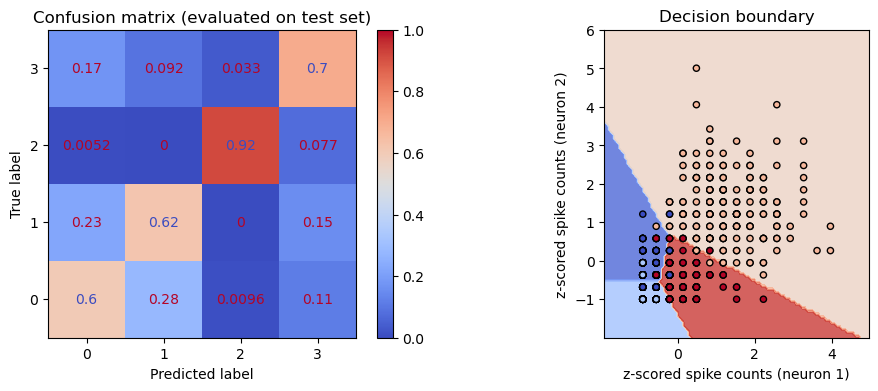

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

disp1 = ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, normalize='true', cmap='coolwarm', ax=axs[0]
)
disp1.im_.set_clim(0, 1)
axs[0].set_title('Confusion matrix (evaluated on test set)')
axs[0].invert_yaxis()

disp1 = DecisionBoundaryDisplay.from_estimator(
        clf, 
        X_test, 
        response_method="predict", 
        cmap=plt.cm.coolwarm, 
        alpha=0.8, 
        ax=axs[1], 
        xlabel='z-scored spike counts (neuron 1)', 
        ylabel='z-scored spike counts (neuron 2)',
    )
axs[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
# axs[1].set_xticks(())
# axs[1].set_yticks(())
axs[1].set_aspect('equal')
axs[1].set_title('Decision boundary')

plt.show()

In [11]:
def ovo_winner(scores, n_classes):
    """
        clf : trained sklearn.svm.SVC with decision_function_shape='ovo' or OneVsOneClassifier(SVC)
        n_classes: int
    """
    n_samples = scores.shape[0]

    # generate class pairs in sklearn order
    pairs = []
    for i in range(n_classes):
        for j in range(i+1, n_classes):
            pairs.append((i, j))

    votes = np.zeros((n_samples, n_classes))

    for k, (i, j) in enumerate(pairs):
        votes[:, i] += (-scores[:, k])
        votes[:, j] += scores[:, k]

    # determine individual winners
    winners_indv = np.zeros((n_samples, len(pairs)))
    for k, (i, j) in enumerate(pairs):
        # boolean mask where vote > 0
        mask = scores[:, k] > 0
    
        # assign class j where mask is True
        winners_indv[mask, k] = j

        # assign class i where mask is False
        winners_indv[~mask, k] = i

    winners = np.argmax(votes, axis=1)
    return winners, winners_indv, votes

In [12]:
scores = clf.decision_function(X_test)
winners, winners_indv, votes = ovo_winner(scores, n_classes=n_bins)
print(np.all(winners == clf.predict(X_test)))

False


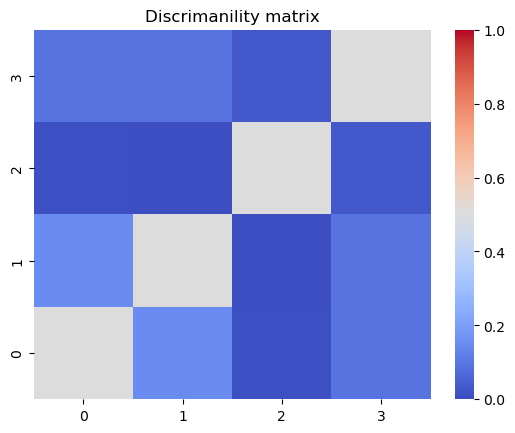

In [13]:
# compute discriminability
pairs = [] # [(0, 1), (0, 2), ..., (3, 4)]
for i in range(n_bins):
    for j in range(i+1, n_bins):
        pairs.append((i, j))

prop_corr = np.zeros(len(pairs))
for j in range(len(y_test)):
    prop_corr += y_test[j] == winners_indv[j]
prop_corr = prop_corr / len(y_test)

# create discriminability matrix
prop_corr_mat = np.zeros((n_bins, n_bins))
for k in range(len(prop_corr)):
    i, j = pairs[k]
    prop_corr_mat[i, j] = prop_corr[k]    
    prop_corr_mat[j, i] = prop_corr[k]  
np.fill_diagonal(prop_corr_mat, 0.5)

# plot discriminability matrix
sns.heatmap(prop_corr_mat, vmin=0, vmax=1, cmap='coolwarm')
plt.title('Discrimanility matrix')
plt.gca().invert_yaxis()